# ⚙️ Engine Production Data Analysis

## Data Science Support
- **GetDataHelp**: [go.ncsu.edu/getdatahelp](https://go.ncsu.edu/getdatahelp)
- **Email**: [getdatahelp@ncsu.edu](mailto:getdatahelp@ncsu.edu)

## Learning Objectives
By the end of this notebook, you will be able to:
1. Load and inspect manufacturing operations data
2. Perform a light but essential data cleaning pass
3. Analyze production, defects, and downtime patterns
4. Use simple statistical checks to support findings
5. Summarize operational insights clearly

## Step 1: Data Loading and Initial Inspection

In this step, we load the dataset and answer:
- How many records and variables do we have?
- What are the data types?
- Are missing values visible at first glance?

### Set up your workspace

- **Goal**: Import any libraries you think are needed to inspect, clean, and analyze the data.

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load and preview the data

- **Goal**: Read the dataset and inspect the first few rows to understand structure and content.

In [7]:
df = pd.read_csv('data/engine_production_data_original.csv')
display(df.head())

,Timestamp,Shift,Day_of_Week,Machine_ID,Model_Type,Production_Count,Defective_Count,Downtime_Min
0,2024-10-21 07:00,1,Monday,M1,V6,46,0.0,5.0
1,2024-10-21 07:00,1,Monday,M2,V8,42,0.0,0.0
2,2024-10-21 07:00,1,Monday,M3,EV-1,32,0.0,0.0
3,2024-10-21 08:00,1,Monday,M1,V6,42,1.0,0.0
4,2024-10-21 08:00,1,Monday,M2,V8,40,1.0,0.0


### Inspect data quality

- **Goal**: Run checks that help you understand data completeness, consistency, and potential issues.

In [8]:
print('Shape:', df.shape)
display(df.dtypes)
display(df.isna().sum().sort_values(ascending=False))
print('Full-row duplicates:', df.duplicated().sum())
print('Duplicates by Timestamp+Machine_ID:', df.duplicated(subset=['Timestamp', 'Machine_ID']).sum())

Shape: (1018, 8)


Timestamp               str
Shift                 int64
Day_of_Week             str
Machine_ID              str
Model_Type              str
Production_Count      int64
Defective_Count     float64
Downtime_Min            str
dtype: object

Defective_Count     24
Downtime_Min        21
Timestamp            0
Shift                0
Day_of_Week          0
Machine_ID           0
Model_Type           0
Production_Count     0
dtype: int64

Full-row duplicates: 10
Duplicates by Timestamp+Machine_ID: 10


## Step 2: Light Data Cleaning (Keep It Focused)

Use your inspection results to decide what should be cleaned before analysis.

Suggested flow:
1. Identify and list data quality issues you observe
2. Prioritize only issues that will affect analysis quality
3. Apply a minimal set of cleaning steps
4. Re-check the data briefly before moving on

**Goal**: Keep cleaning practical and short; the main focus is analysis.

### List cleaning decisions

- **Goal**: Based on your inspection, summarize what you will clean and why (briefly).

In [9]:
day_map = {
    'Mon': 'Monday', 'Tue': 'Tuesday', 'Wed': 'Wednesday',
    'Thu': 'Thursday', 'Fri': 'Friday', 'Sat': 'Saturday', 'Sun': 'Sunday'
}
df['Day_of_Week'] = df['Day_of_Week'].replace(day_map)
df['Model_Type'] = df['Model_Type'].str.upper()

print('Day_of_Week categories:', sorted(df['Day_of_Week'].unique()))
print('Model_Type categories:', sorted(df['Model_Type'].unique()))

Day_of_Week categories: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
Model_Type categories: ['EV-1', 'V6', 'V8']


### Apply cleaning step 1

- **Goal**: Implement the first set of cleaning actions you decided on.

In [10]:
numeric_cols = ['Production_Count', 'Defective_Count', 'Downtime_Min']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['Defective_Count'] = df['Defective_Count'].fillna(0)
df['Downtime_Min'] = df['Downtime_Min'].fillna(0)

before_filters = len(df)
df = df[df['Production_Count'] >= 0]
df = df[df['Defective_Count'] <= df['Production_Count']]
after_filters = len(df)

print('Rows removed by validity filters:', before_filters - after_filters)
print('Rows remaining:', after_filters)

Rows removed by validity filters: 6
Rows remaining: 1012


### Apply cleaning step 2 and validate

- **Goal**: Finish cleaning, then run a quick post-cleaning check before analysis.

In [11]:
before_dedup = len(df)
df = df.drop_duplicates()
print('Dropped duplicate rows:', before_dedup - len(df))

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df[df['Timestamp'].notna()].copy()
df['Date'] = df['Timestamp'].dt.date
df['Hour'] = df['Timestamp'].dt.hour

display(df.head())

Dropped duplicate rows: 10


,Timestamp,Shift,Day_of_Week,Machine_ID,Model_Type,Production_Count,Defective_Count,Downtime_Min,Date,Hour
0,2024-10-21 07:00:00,1,Monday,M1,V6,46,0.0,5.0,2024-10-21,7
1,2024-10-21 07:00:00,1,Monday,M2,V8,42,0.0,0.0,2024-10-21,7
2,2024-10-21 07:00:00,1,Monday,M3,EV-1,32,0.0,0.0,2024-10-21,7
3,2024-10-21 08:00:00,1,Monday,M1,V6,42,1.0,0.0,2024-10-21,8
4,2024-10-21 08:00:00,1,Monday,M2,V8,40,1.0,0.0,2024-10-21,8


## Step 3: Exploratory Data Analysis

### 3.1 Initial Pattern Discovery
Start by exploring broad patterns you notice in the cleaned data.

### Explore production and quality patterns

- **Goal**: Create at least one summary view that compares production and quality across key groups.

In [12]:
machine_summary = df.groupby('Machine_ID', as_index=False).agg(
    Production_Total=('Production_Count', 'sum'),
    Defective_Total=('Defective_Count', 'sum')
)
machine_summary['Defect_Rate'] = machine_summary['Defective_Total'] / machine_summary['Production_Total']
machine_summary = machine_summary.sort_values('Defect_Rate', ascending=False)
display(machine_summary)

,Machine_ID,Production_Total,Defective_Total,Defect_Rate
1,M2,12164,245.0,0.020141
3,M99,124,2.0,0.016129
0,M1,14722,152.0,0.010325
2,M3,9878,40.0,0.004049


### Build a comparison visualization

- **Goal**: Plot one clear chart that compares groups relevant to your first findings.

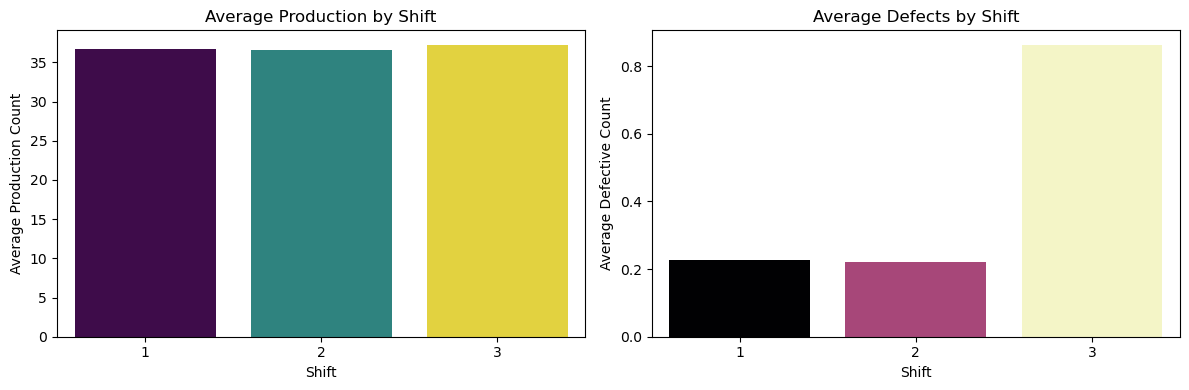

In [19]:
shift_means = df.groupby('Shift', as_index=False).agg(
    Avg_Production=('Production_Count', 'mean'),
    Avg_Defects=('Defective_Count', 'mean')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=shift_means, x='Shift', y='Avg_Production', hue='Shift', legend=False, ax=axes[0], palette='viridis')
axes[0].set_title('Average Production by Shift')
axes[0].set_xlabel('Shift')
axes[0].set_ylabel('Average Production Count')

sns.barplot(data=shift_means, x='Shift', y='Avg_Defects', hue='Shift', legend=False, ax=axes[1], palette='magma')
axes[1].set_title('Average Defects by Shift')
axes[1].set_xlabel('Shift')
axes[1].set_ylabel('Average Defective Count')

plt.tight_layout()
plt.show()

### Add a second perspective

- **Goal**: Create another summary or visualization that reveals a different quality/performance angle.

,Model_Type,Production_Total,Defective_Total,Defect_Rate
2,V8,12244,247.0,0.020173
1,V6,14766,152.0,0.010294
0,EV-1,9878,40.0,0.004049


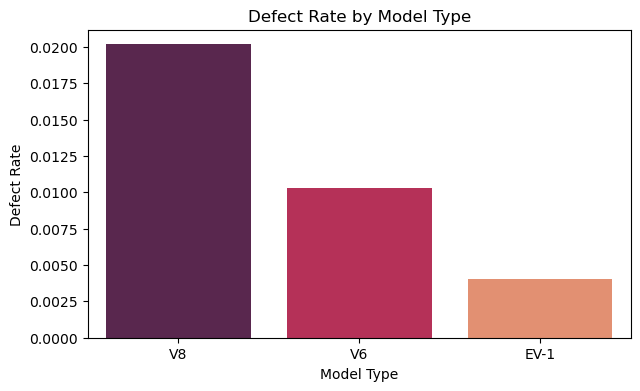

In [20]:
model_summary = df.groupby('Model_Type', as_index=False).agg(
    Production_Total=('Production_Count', 'sum'),
    Defective_Total=('Defective_Count', 'sum')
)
model_summary['Defect_Rate'] = model_summary['Defective_Total'] / model_summary['Production_Total']
model_summary = model_summary.sort_values('Defect_Rate', ascending=False)
display(model_summary)

plt.figure(figsize=(7, 4))
sns.barplot(data=model_summary, x='Model_Type', y='Defect_Rate', hue='Model_Type', legend=False, palette='rocket')
plt.title('Defect Rate by Model Type')
plt.xlabel('Model Type')
plt.ylabel('Defect Rate')
plt.show()

### 3.2 Follow-up Exploration
Based on your first findings, investigate a second angle that seems important.

### Explore another pattern

- **Goal**: Build a table or grouped summary for a second pattern you think is important.

In [15]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_downtime = df.pivot_table(
    index='Day_of_Week',
    columns='Shift',
    values='Downtime_Min',
    aggfunc='mean'
).reindex(day_order)
display(pivot_downtime.round(2))

Shift,1,2,3
Day_of_Week,,,
Monday,4.04,4.31,2.85
Tuesday,5.44,2.19,2.54
Wednesday,3.31,3.12,3.73
Thursday,2.38,4.19,3.67
Friday,3.87,3.81,1.35
Saturday,3.21,4.02,2.13
Sunday,4.96,2.73,1.98


### Visualize your selected pattern

- **Goal**: Create a plot that communicates your second pattern clearly.

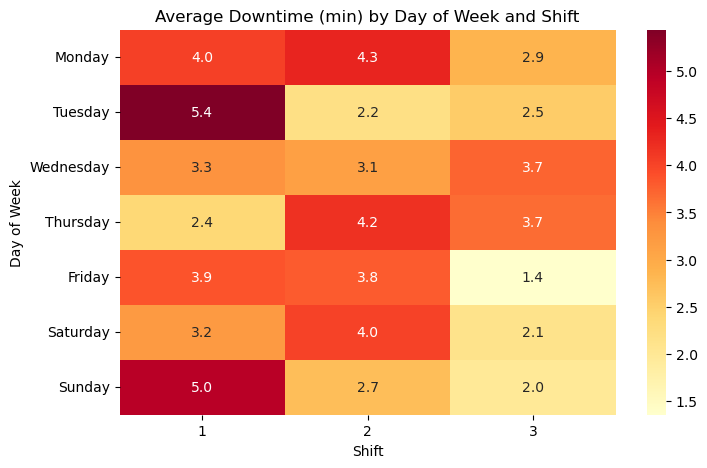

In [16]:
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_downtime, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Average Downtime (min) by Day of Week and Shift')
plt.xlabel('Shift')
plt.ylabel('Day of Week')
plt.show()

## Step 4: Simple Statistical Check

### Research Question
Choose one testable question that came from your exploration and evaluate it with an appropriate statistical method.

Interpret the result in plain language.

### Run one statistical check

- **Goal**: Choose and run one appropriate statistical test tied to your analysis question.

In [17]:
from scipy.stats import kruskal

downtime_by_shift = [
    df.loc[df['Shift'] == s, 'Downtime_Min'] for s in sorted(df['Shift'].unique())
]
stat, p_value = kruskal(*downtime_by_shift)

print(f'Kruskal-Wallis statistic: {stat:.4f}')
print(f'p-value: {p_value:.6f}')

alpha = 0.05
if p_value < alpha:
    print('Conclusion: Downtime differs significantly across shifts.')
else:
    print('Conclusion: No statistically significant downtime difference across shifts.')

Kruskal-Wallis statistic: 3.7948
p-value: 0.149961
Conclusion: No statistically significant downtime difference across shifts.


## Step 5: Conclusions and Next Steps

Summarize:
1. The most important patterns you found
2. Why these patterns matter
3. One limitation or uncertainty in your analysis
4. One practical next step or recommendation

### Summarize findings

- **Goal**: Write concise, evidence-based conclusions and one practical recommendation.

In [18]:
best_machine = machine_summary.sort_values('Defect_Rate').iloc[0]
worst_machine = machine_summary.sort_values('Defect_Rate', ascending=False).iloc[0]
highest_downtime_shift = df.groupby('Shift')['Downtime_Min'].mean().idxmax()

print(f"- Best quality machine: {best_machine['Machine_ID']} (lowest defect rate: {best_machine['Defect_Rate']:.3f})")
print(f"- Highest defect pressure: {worst_machine['Machine_ID']} (highest defect rate: {worst_machine['Defect_Rate']:.3f})")
print(f"- Highest average downtime occurs in Shift {highest_downtime_shift}.")
print('- Model-level quality differs; prioritize root-cause checks for the highest defect-rate model.')
print('- Recommendation: target preventive maintenance and staffing adjustments for high-downtime shifts.')

- Best quality machine: M3 (lowest defect rate: 0.004)
- Highest defect pressure: M2 (highest defect rate: 0.020)
- Highest average downtime occurs in Shift 1.
- Model-level quality differs; prioritize root-cause checks for the highest defect-rate model.
- Recommendation: target preventive maintenance and staffing adjustments for high-downtime shifts.
